In [2]:
import pickle 
from matplotlib import pyplot as plt
import casadi as cs
import numpy as np
from NMM.solver import Continuation_Solver
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib import animation
from matplotlib.gridspec import GridSpec


np.set_printoptions(precision=6, suppress=True)
bgColor = '#24273a'
mainColor = '#cad3f5'

In [3]:
def prettify(ax,xlabel='',ylabel='',title='',fgColor='#cad3f5',bgColor='#24273a',fontsize=14):
    ax.set_xlabel(xlabel,fontsize=fontsize,color=fgColor)
    ax.set_ylabel(ylabel,fontsize=fontsize,color=fgColor)
    ax.set_title(title,fontsize=fontsize,color=fgColor)
    ax.spines['bottom'].set_color(fgColor)
    ax.spines['top'].set_color(fgColor)
    ax.spines['left'].set_color(fgColor)
    ax.spines['right'].set_color(fgColor)
    ax.xaxis.label.set_color(fgColor)
    ax.yaxis.label.set_color(fgColor)
    ax.tick_params(axis='x', colors=fgColor)
    ax.tick_params(axis='y', colors=fgColor)
    ax.set_facecolor(bgColor)

In [4]:
def prettify3D(ax,xlabel='',ylabel='',zlabel='',title='',fgColor='#cad3f5',bgColor='#24273a',fontsize=18):
    ax.set_xlabel(xlabel,fontsize=fontsize,color=fgColor)
    ax.set_ylabel(ylabel,fontsize=fontsize,color=fgColor)
    ax.set_zlabel(zlabel,fontsize=fontsize,color=fgColor)
    ax.set_title(title,fontsize=fontsize,color=fgColor)
    ax.xaxis.line.set_color(fgColor)
    ax.yaxis.line.set_color(fgColor)
    ax.zaxis.line.set_color(fgColor)
    ax.tick_params(axis='x', colors=fgColor)
    ax.tick_params(axis='y', colors=fgColor)
    ax.tick_params(axis='z', colors=fgColor)
    ax.xaxis.label.set_color(fgColor)
    ax.yaxis.label.set_color(fgColor)
    ax.zaxis.label.set_color(fgColor)
    ax.set_facecolor(bgColor)
    frame = ax.legend(fontsize=fontsize,labelcolor=fgColor,loc='upper right').get_frame()
    frame.set_facecolor(bgColor)
    frame.set_edgecolor(fgColor)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(fgColor)
    ax.yaxis.pane.set_edgecolor(fgColor)
    ax.zaxis.pane.set_edgecolor(fgColor)

In [5]:
def spring(start, end, nodes, width):
    nodes = max(int(nodes), 1)

    start, end = np.array(start).reshape((2,)), np.array(end).reshape((2,))

    if (start == end).all():
        return start[0], start[1]

    length = np.linalg.norm(np.subtract(end, start))

    u_t = np.subtract(end, start) / length
    u_n = np.array([[0, -1], [1, 0]]).dot(u_t)

    spring_coords = np.zeros((2, nodes + 2))
    spring_coords[:,0], spring_coords[:,-1] = start, end

    normal_dist = np.sqrt(max(0, width**2 - (length**2 / nodes**2))) / 2

    for i in range(1, nodes + 1):
        spring_coords[:,i] = (
            start
            + ((length * (2 * i - 1) * u_t) / (2 * nodes))
            + (normal_dist * (-1)**i * u_n))

    return spring_coords[0,:], spring_coords[1,:]

In [6]:
def traj(solver,u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = solver.traj_f_list(x0, dt[0], xi)
    traj2 = solver.stance_to_flight(
        solver.traj_s_list(solver.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = solver.traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    traj = cs.horzcat(traj1, traj2, traj3, traj1[:,0])
    return np.array(traj)

In [7]:
def get_surface(N,data,solver):
    surface = np.zeros((N,6,2*solver.N_F + solver.N_S + 1))
    fcolor = np.zeros((N,2*solver.N_F + solver.N_S + 1))
    for i in range(N):
        surface[i,:,:] = traj(solver,data[int(i*2000/N)])
        fcolor[i,:] = data[int(i*2000/N)][-1]
    return surface,fcolor

In [8]:
solver = Continuation_Solver(40,cs.sqrt(10),1000,0.01,True)

In [9]:
data_locomotion = pickle.load(open('data/data_locomotion.pkl', 'rb'))
data_switch = pickle.load(open('data/data_switch.pkl', 'rb'))
data_test = pickle.load(open('data/data_test.pkl', 'rb'))


In [10]:
def reorder(branch):
    traj = np.array(branch)
    idx = 0
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 0.02:
            idx = i+1
    fixed_traj = np.vstack([np.flip(traj[:idx,:],axis=0),traj[idx:,:]])
    if traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        fixed_traj[:,[0,2,3,5]] = - fixed_traj[:,[0,2,3,5]]
    return fixed_traj

def separate(traj):
    idx = 0
    for i in range(100,traj.shape[0] -101):
        de1 = traj[i,-1] - traj[i-1,-1]
        de2 = traj[i+1,-1] - traj[i,-1]
        if de1*de2 < 0:
            idx = i + 1
    return traj[:idx,:],traj[idx:,:]

L1 = reorder(data_locomotion[2])
L11,L12 = separate(L1)
L2 = reorder(data_locomotion[4])
L21,L22 = separate(L2)
L3 = reorder(data_locomotion[6])
L31,L32 = separate(L3)
L4 = reorder(data_locomotion[8])
L41,L42 = separate(L4)

S1 = reorder(data_switch[2])
S2 = reorder(data_switch[4])


# plt.plot(S1[:,1])
# plt.plot(S2[:,1])
# plt.plot(L2[:,1])
# plt.plot(L22[:,1])

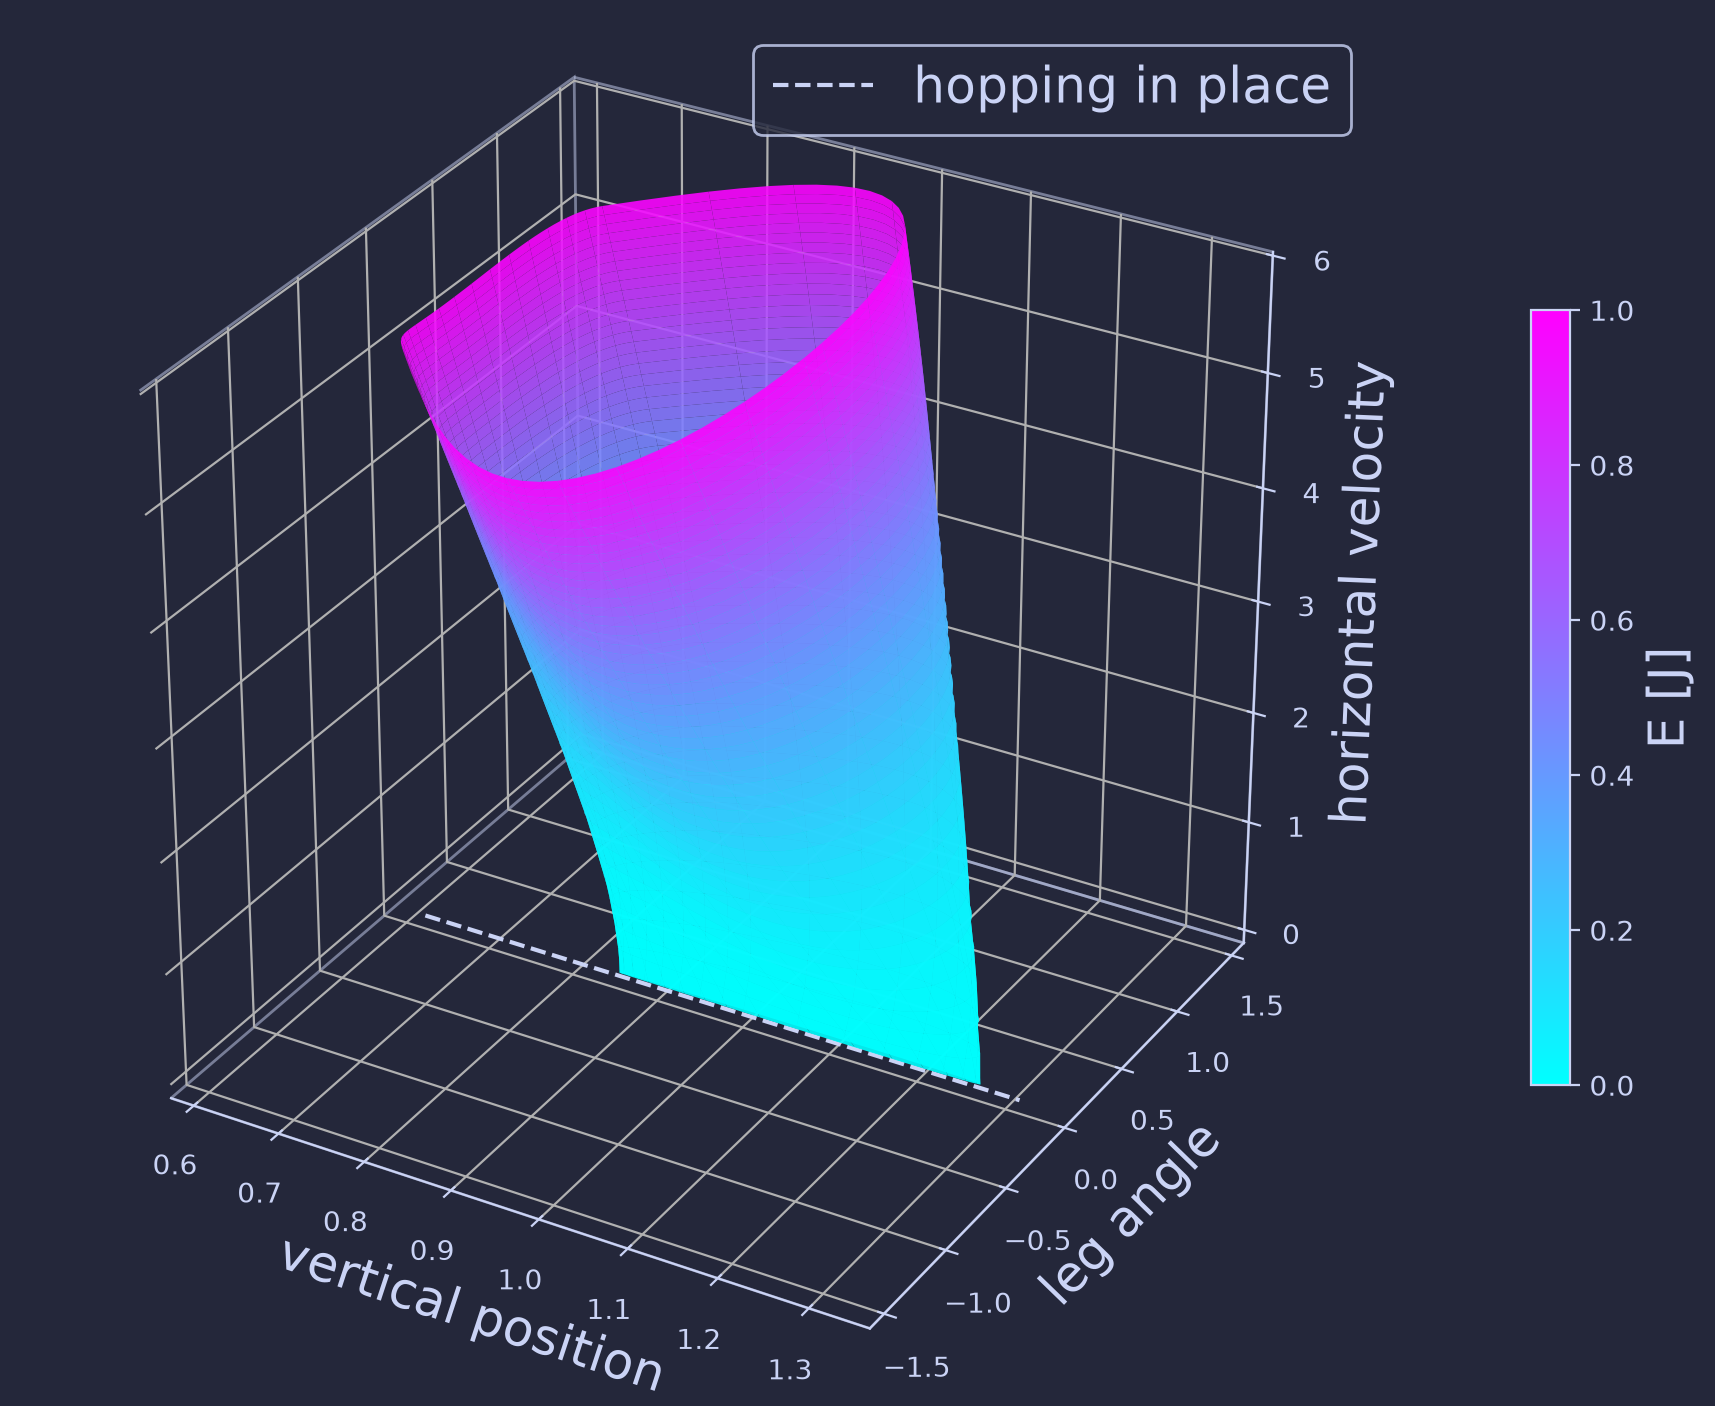

In [10]:
from matplotlib import colorbar,colors,colorizer

idx = [1,2,3]
Nframes = 600

surface_locomotion,faces = get_surface(50,data_locomotion[4],solver)
norm = colors.Normalize(vmin=faces.min(), vmax=faces.max())
fcolor = cm.cool(norm(faces))[:-1, :-1]
fig_surface = plt.figure(figsize=(10,10),facecolor=bgColor,dpi=200)
ax = fig_surface.add_subplot(1,1,1,projection='3d')
ax.plot_surface(surface_locomotion[:,idx[0]], surface_locomotion[:,idx[1]], surface_locomotion[:,idx[2]],facecolors=fcolor,shade=False, edgecolor='none', alpha=0.9)
# ax.plot(surface_locomotion[:,idx[0],solver.N_F],surface_locomotion[:,idx[1],solver.N_F],surface_locomotion[:,idx[2],solver.N_F],linewidth = 2, color='#ffff00', label='generator')
x_min,x_max = ax.get_xlim()


col = colorizer.Colorizer(norm=colors.Normalize(0,1), cmap='cool')

cbar = fig_surface.colorbar(colorizer.ColorizingArtist(col),
             ax=ax, orientation='vertical', fraction=0.025,pad=0.1, aspect=20)

cbar.outline.set_edgecolor(mainColor)
cbar.ax.tick_params(axis='y', colors=mainColor)
cbar.set_label('E [J]', color=mainColor,fontsize=18)

ax.plot([x_min,x_max],[0,0],[0,0],'--',color=mainColor,label='hopping in place')
ax.legend()
prettify3D(ax,xlabel='vertical position', ylabel='leg angle', zlabel='horizontal velocity')
ax.set_box_aspect((4,4,4))
ax.grid('off')
plt.show()

def animate(i):
    # ax.view_init(elev=35. - 20/Nframes * i, azim=45+(360/(3*Nframes)) * i)
    ax.view_init(elev=20, azim=45+(360/(Nframes)) * i)


ani = animation.FuncAnimation(
    fig_surface, animate, Nframes, interval=1, blit=True)

writervideo = animation.FFMpegWriter(fps=30) 
ani.save('output/surface.mp4', writer=writervideo, savefig_kwargs=dict(facecolor=bgColor)) 

(50, 6, 101)


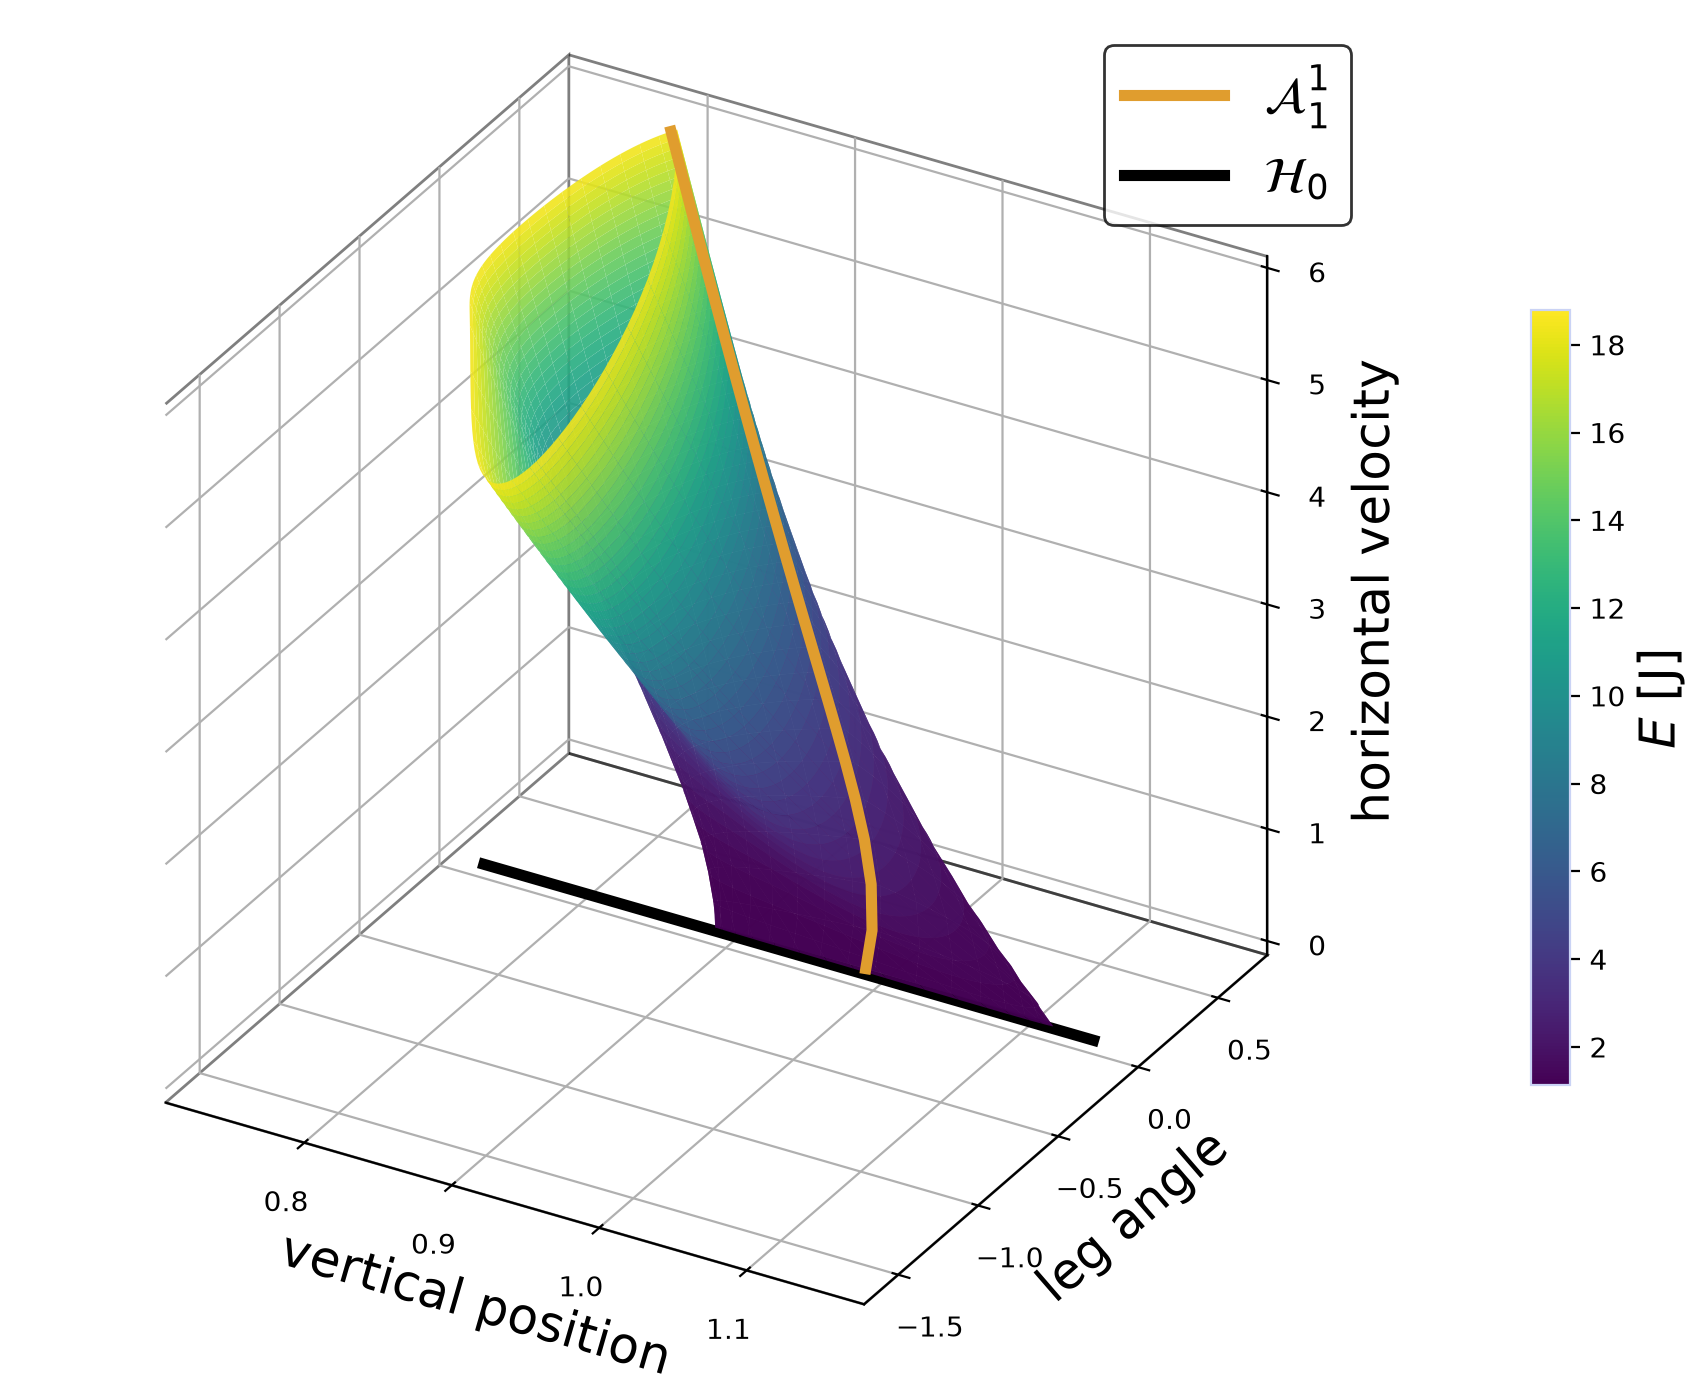

In [51]:
from matplotlib import colorbar,colors,colorizer

idx = [1,2,3]
Nframes = 600

surface_locomotion,faces = get_surface(50,data_locomotion[2],solver)
norm = colors.Normalize(vmin=faces.min(), vmax=faces.max())
fcolor = cm.viridis(norm(faces))[:-1, :-1]
fig_surface = plt.figure(figsize=(10,10),facecolor='white',dpi=200)
ax = fig_surface.add_subplot(1,1,1,projection='3d')
ax.set_proj_type('ortho')
ax.plot_surface(surface_locomotion[:,idx[0]], surface_locomotion[:,idx[1]], surface_locomotion[:,idx[2]],facecolors=fcolor,shade=False, edgecolor='none', alpha=0.9)
ax.plot(surface_locomotion[:,idx[0],solver.N_F],surface_locomotion[:,idx[1],solver.N_F],surface_locomotion[:,idx[2],solver.N_F],linewidth = 4, color='#e09d2eff', label=r'$\mathcal{A}_1^1$',zorder=10)
x_min,x_max = ax.get_xlim()
print(surface_locomotion.shape)

col = colorizer.Colorizer(norm=colors.Normalize(surface_locomotion[0,1,0]+0.5*surface_locomotion[0,3,0]**2,surface_locomotion[-1,1,0]+0.5*surface_locomotion[-1,3,0]**2), cmap='viridis')

cbar = fig_surface.colorbar(colorizer.ColorizingArtist(col),
             ax=ax, orientation='vertical', fraction=0.025,pad=0.1, aspect=20)

cbar.outline.set_edgecolor(mainColor)
cbar.ax.tick_params(axis='y')
cbar.set_label(r'$E$ [J]',fontsize=18)

ax.plot([x_min,x_max],[0,0],[0,0],color='k',label=r'$\mathcal{H}_0$',linewidth=4)
ax.legend()
# ax.view_init(elev=25, azim=65)
prettify3D(ax,xlabel='vertical position', ylabel='leg angle', zlabel='horizontal velocity',bgColor='white',fgColor='black')
ax.set_box_aspect((4,4,4))
ax.grid('off')
plt.savefig('A1_closeup.svg')



In [52]:
def plot_traj(ax,traj,c,lw=0.5):
    ax.plot(traj[1,:],traj[2,:],traj[3,:], linewidth=lw,color=c)

def plot_generator(ax,branch,c,lw,STEP_SIZE,IDX,linestyle='-',d=1,plot_TP=False):
    traj = np.array(branch)
    idx = 0
    idx_TP = []
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 2*STEP_SIZE:
            idx = i
        if plot_TP and i>20 and i<traj.shape[0]-20 and np.linalg.det(solver.compute_Jz(traj[i+1,:10],traj[i+1,10])) * np.linalg.det(solver.compute_Jz(traj[i,:10],traj[i,10]))<0:
            idx_TP.append(i)

    if traj[-1,3] > 1e-2 or traj[0,3] > 1e-2:
        ax.plot(traj[:idx+1,IDX[0]],d*traj[:idx+1,IDX[1]],d*traj[:idx+1,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],d*traj[idx+1:,IDX[1]],d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx,IDX[0]],d*traj[idx,IDX[1]],d*traj[idx,IDX[2]],marker='o' if np.abs(traj[idx,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        ax.plot(traj[-1,IDX[0]],d*traj[-1,IDX[1]],d*traj[-1,IDX[2]],marker='o' if np.abs(traj[-1,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        for i in idx_TP:
            ax.plot(traj[i,IDX[0]],d*traj[i,IDX[1]],d*traj[i,IDX[2]],marker='d' ,ms=10,color='#fe7f2d')

    elif traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        ax.plot(traj[:idx,IDX[0]],-d*traj[:idx,IDX[1]],-d*traj[:idx,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],-d*traj[idx+1:,IDX[1]],-d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx,IDX[0]],-d*traj[idx,IDX[1]],-d*traj[idx,IDX[2]],marker='o' if np.abs(traj[idx,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        ax.plot(traj[-1,IDX[0]],-d*traj[-1,IDX[1]],-d*traj[-1,IDX[2]],marker='o' if np.abs(traj[-1,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        for i in idx_TP:
            ax.plot(traj[i,IDX[0]],-d*traj[i,IDX[1]],-d*traj[i,IDX[2]],marker='d' ,ms=10,color='#fe7f2d')



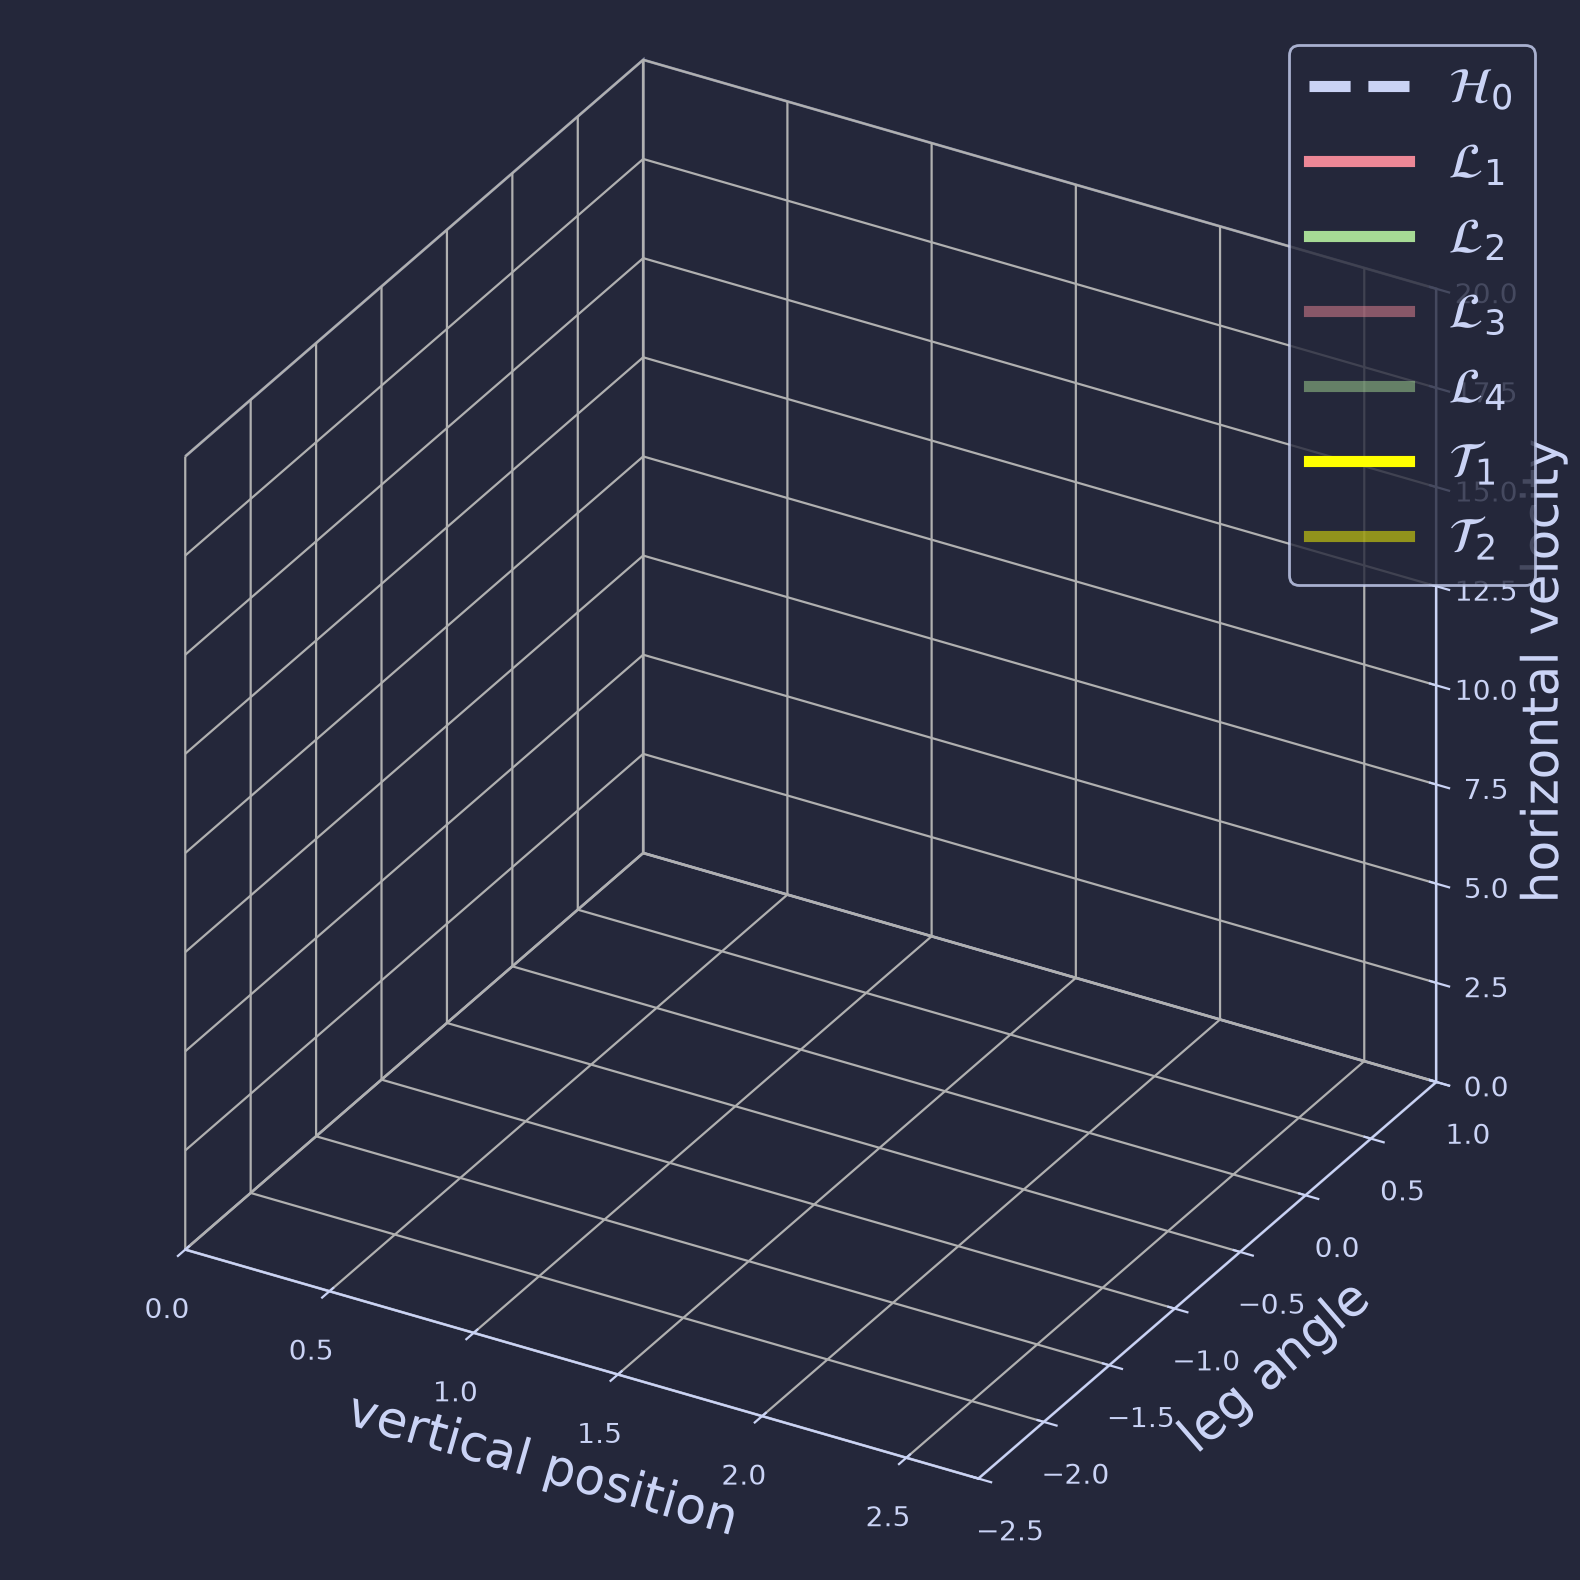

In [51]:
Emax = max(L1[:,-1])
fig_generator = plt.figure(figsize=(10,10),facecolor=bgColor,dpi=200)
Nframes = 300
Elist = np.geomspace(1,Emax,Nframes)
ylist = np.linspace(1,2.6,1000)
ax = fig_generator.add_subplot(1,1,1,projection='3d')
ax.set_proj_type('ortho')
ax.set_box_aspect((4,4,4))

def animate(i):
    # ax.view_init(elev=35. - 20/Nframes * i, azim=45-(360/(3*Nframes)) * i)
    # ax.view_init(elev=20, azim=45+(360/(Nframes)) * i)
    Elim = Elist[i]
    plot_L11.set_data_3d(
        L11[np.argwhere(L11[:,-1]<=Elim).reshape((-1,)),1],
        L11[np.argwhere(L11[:,-1]<=Elim).reshape((-1,)),2],
        L11[np.argwhere(L11[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L22.set_data_3d(
        L22[np.argwhere(L22[:,-1]<=Elim).reshape((-1,)),1],
        L22[np.argwhere(L22[:,-1]<=Elim).reshape((-1,)),2],
        L22[np.argwhere(L22[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L31.set_data_3d(
        L31[np.argwhere(L31[:,-1]<=Elim).reshape((-1,)),1],
        L31[np.argwhere(L31[:,-1]<=Elim).reshape((-1,)),2],
        L31[np.argwhere(L31[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L42.set_data_3d(
        L42[np.argwhere(L42[:,-1]<=Elim).reshape((-1,)),1],
        L42[np.argwhere(L42[:,-1]<=Elim).reshape((-1,)),2],
        L42[np.argwhere(L42[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L12.set_data_3d(
        L12[np.argwhere(L12[:,-1]<=Elim).reshape((-1,)),1],
        L12[np.argwhere(L12[:,-1]<=Elim).reshape((-1,)),2],
        L12[np.argwhere(L12[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L21.set_data_3d(
        L21[np.argwhere(L21[:,-1]<=Elim).reshape((-1,)),1],
        L21[np.argwhere(L21[:,-1]<=Elim).reshape((-1,)),2],
        L21[np.argwhere(L21[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L32.set_data_3d(
        L32[np.argwhere(L32[:,-1]<=Elim).reshape((-1,)),1],
        L32[np.argwhere(L32[:,-1]<=Elim).reshape((-1,)),2],
        L32[np.argwhere(L32[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L41.set_data_3d(
        L41[np.argwhere(L41[:,-1]<=Elim).reshape((-1,)),1],
        L41[np.argwhere(L41[:,-1]<=Elim).reshape((-1,)),2],
        L41[np.argwhere(L41[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_S1.set_data_3d(
        S1[np.argwhere(S1[:,-1]<=Elim).reshape((-1,)),1],
        S1[np.argwhere(S1[:,-1]<=Elim).reshape((-1,)),2],
        S1[np.argwhere(S1[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_S2.set_data_3d(
        S2[np.argwhere(S2[:,-1]<=Elim).reshape((-1,)),1],
        S2[np.argwhere(S2[:,-1]<=Elim).reshape((-1,)),2],
        S2[np.argwhere(S2[:,-1]<=Elim).reshape((-1,)),3]
    )
    ydata = ylist[np.argwhere(ylist<=Elim)]
    plot_L0.set_data_3d(ydata.reshape((-1,)),np.zeros((ydata.shape[0],)),np.zeros((ydata.shape[0],)))
 

# for c,M in zip(['#8aadf4','#a6da95','#8aadf4','#a6da95'],[data_locomotion[i] for i in [2,4,6,8]]):
#     plot_generator(ax,M,c,2,0.01,idx,plot_TP=False)
# for M in [data_switch[i] for i in [2,4]]:
#     plot_generator(ax,M,'#ed8796',2,0.01,idx,linestyle='-.',plot_TP=False)
# x_min,x_max = ax.get_xlim()
# ax.plot([x_min,x_max],[0,0],[0,0],'--',zorder=0,color=mainColor)

ax.set_xlim(0,2.75)
ax.set_ylim([-2.5,1])
ax.set_zlim(0,20)

(plot_L0,) = ax.plot([],[],[],color='#cad3f5',linewidth=4,linestyle='--',label=r'$\mathcal{H}_0$')
(plot_L11,) = ax.plot([],[],[],color='#ed8796',linewidth=4,label=r'$\mathcal{L}_1$')
(plot_L21,) = ax.plot([],[],[],color='#a6da95',linewidth=4,label=r'$\mathcal{L}_2$')
(plot_L31,) = ax.plot([],[],[],color='#ed8796',alpha=0.5,linewidth=4,label=r'$\mathcal{L}_3$')
(plot_L41,) = ax.plot([],[],[],color='#a6da95',alpha=0.5,linewidth=4,label=r'$\mathcal{L}_4$')
(plot_L12,) = ax.plot([],[],[],color='#ed8796',linewidth=4)
(plot_L22,) = ax.plot([],[],[],color='#a6da95',linewidth=4)
(plot_L32,) = ax.plot([],[],[],color='#ed8796',alpha=0.5,linewidth=4)
(plot_L42,) = ax.plot([],[],[],color='#a6da95',alpha=0.5,linewidth=4)
(plot_S1,) = ax.plot([],[],[],color='#ffff00',linewidth=4,label=r'$\mathcal{T}_1$')
(plot_S2,) = ax.plot([],[],[],color='#ffff00',linewidth=4, alpha = 0.5,label=r'$\mathcal{T}_2$')
# plot_L12, = ax.plot([],[],[],color='#8bd5ca',linewidth=2)

prettify3D(ax,xlabel='vertical position', ylabel='leg angle', zlabel='horizontal velocity')
plt.show()

ani = animation.FuncAnimation(
    fig_generator, animate, Nframes, interval=1, blit=True)

writervideo = animation.FFMpegWriter(fps=30) 
ani.save('output/generators.mp4', writer=writervideo, savefig_kwargs=dict(facecolor=bgColor)) 

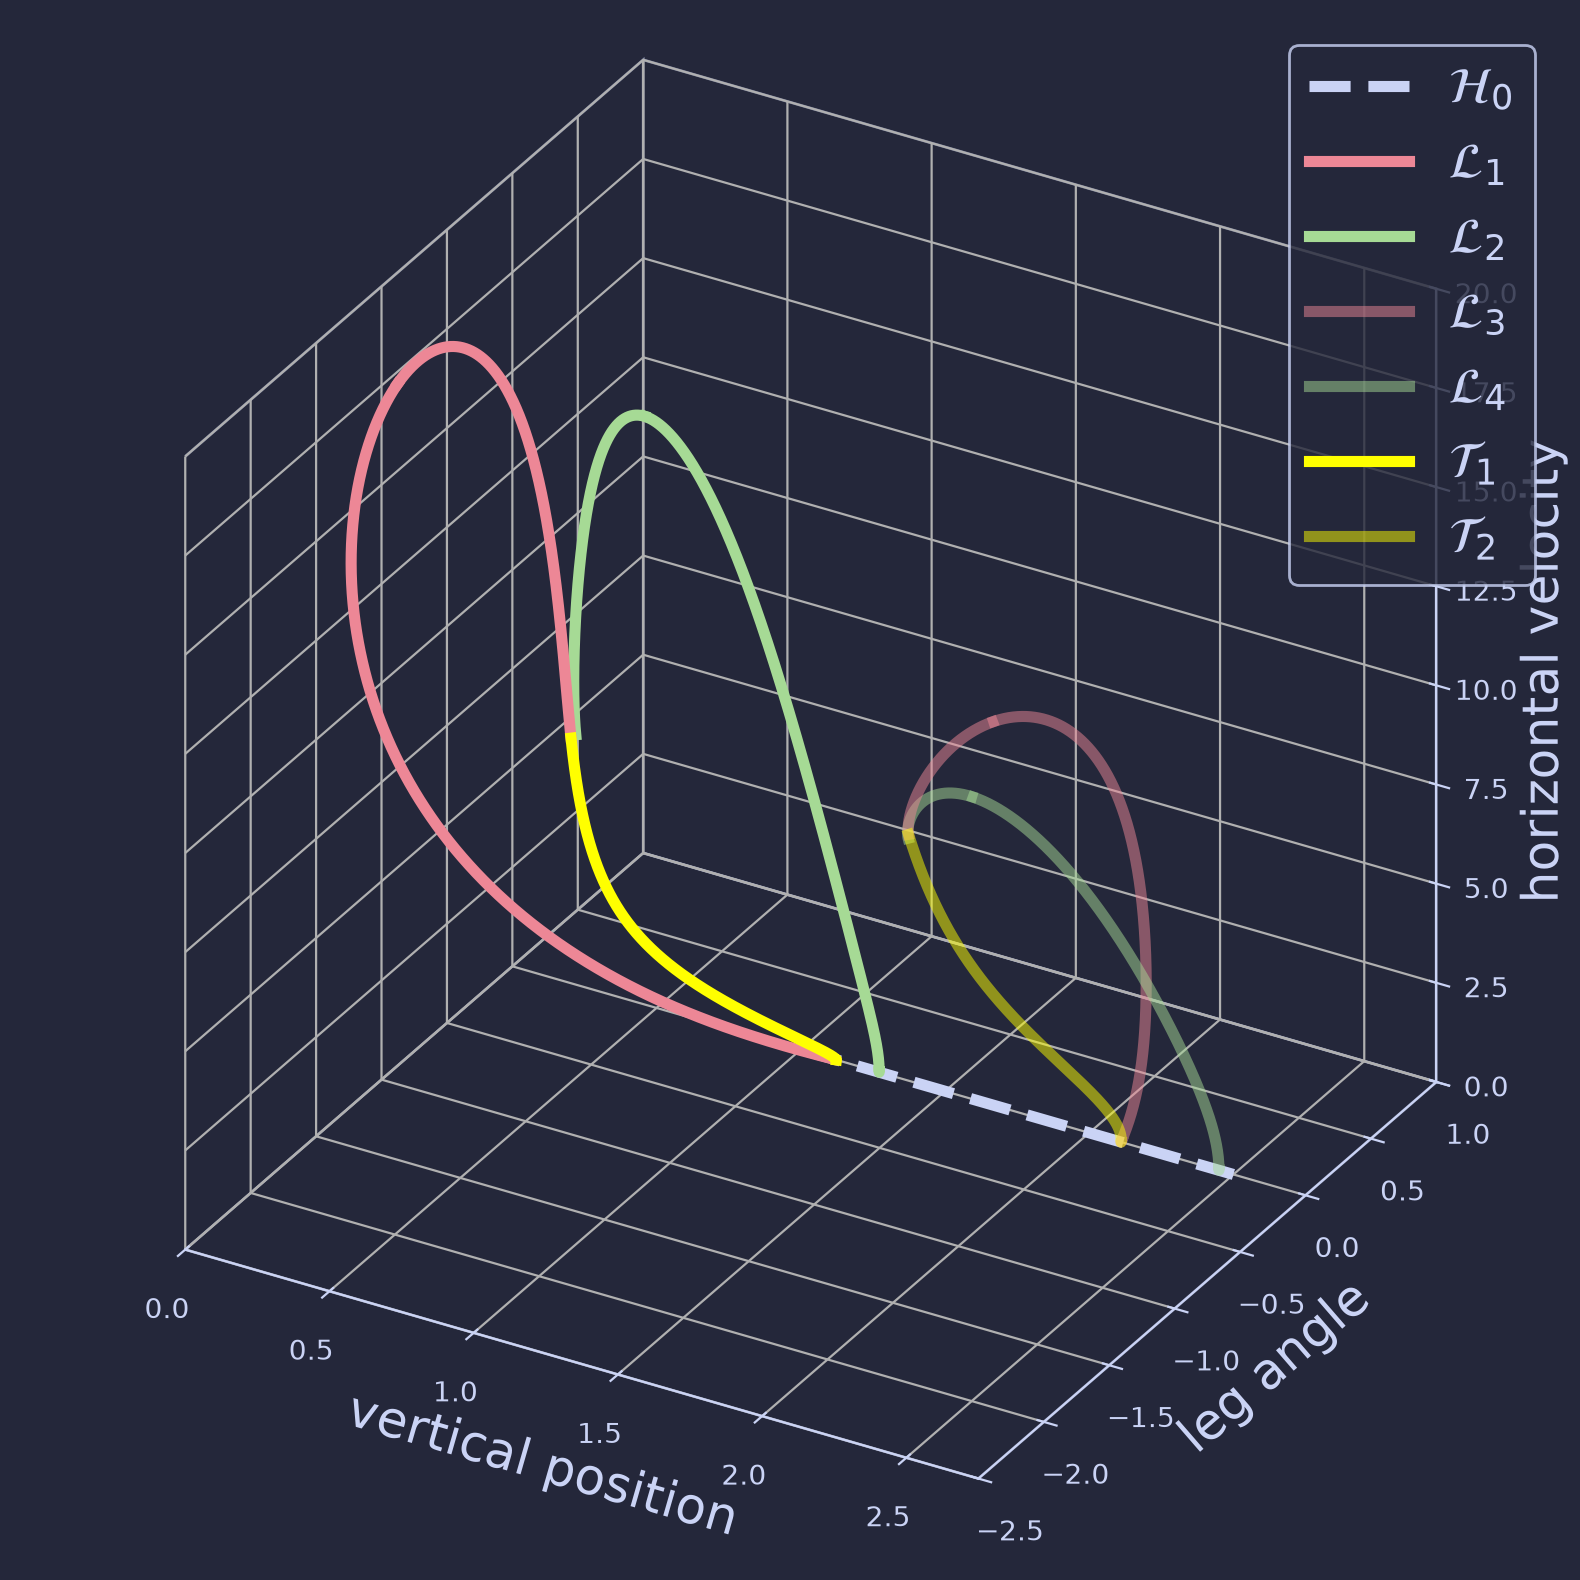

In [53]:
fig_generator = plt.figure(figsize=(10,10),facecolor=bgColor,dpi=200)
ax = fig_generator.add_subplot(1,1,1,projection='3d')
ax.set_proj_type('ortho')
ax.set_box_aspect((4,4,4))

ax.set_xlim(0,2.75)
ax.set_ylim([-2.5,1])
ax.set_zlim(0,20)

(plot_L0,) = ax.plot([1,2.5],[0,0],[0,0],color='#cad3f5',linewidth=4,linestyle='--',label=r'$\mathcal{H}_0$')
(plot_L11,) = ax.plot(L11[:,1],L11[:,2],L11[:,3],color='#ed8796',linewidth=4,label=r'$\mathcal{L}_1$')
(plot_L21,) = ax.plot(L21[:,1],L21[:,2],L21[:,3],color='#a6da95',linewidth=4,label=r'$\mathcal{L}_2$')
(plot_L31,) = ax.plot(L31[:,1],L31[:,2],L31[:,3],color='#ed8796',alpha=0.5,linewidth=4,label=r'$\mathcal{L}_3$')
(plot_L41,) = ax.plot(L41[:,1],L41[:,2],L41[:,3],color='#a6da95',alpha=0.5,linewidth=4,label=r'$\mathcal{L}_4$')
(plot_L12,) = ax.plot(L12[:,1],L12[:,2],L12[:,3],color='#ed8796',linewidth=4)
(plot_L22,) = ax.plot(L22[:,1],L22[:,2],L22[:,3],color='#a6da95',linewidth=4)
(plot_L32,) = ax.plot(L32[:,1],L32[:,2],L32[:,3],color='#ed8796',alpha=0.5,linewidth=4)
(plot_L42,) = ax.plot(L42[:,1],L42[:,2],L42[:,3],color='#a6da95',alpha=0.5,linewidth=4)
(plot_S1,) = ax.plot(S1[:,1],S1[:,2],S1[:,3],color='#ffff00',linewidth=4,label=r'$\mathcal{T}_1$')
(plot_S2,) = ax.plot(S2[:,1],S2[:,2],S2[:,3],color='#ffff00',linewidth=4, alpha = 0.5,label=r'$\mathcal{T}_2$')
# plot_L12, = ax.plot([],[],[],color='#8bd5ca',linewidth=2)

prettify3D(ax,xlabel='vertical position', ylabel='leg angle', zlabel='horizontal velocity')
plt.savefig('generators.svg')


In [53]:


def interpolate_trajectory(traj,tf,fps):
    times = np.linspace(0,tf,traj.shape[1])
    N_frames = int(tf*fps)
    T = np.linspace(0,tf,N_frames)
    xh = np.zeros((traj.shape[0],N_frames))
    i_ = 0
    for i in range(N_frames):
        while T[i] > times[i_+1]:
            i_+=1
        alpha = (T[i] - times[i_])/(times[i_+1]-times[i_])
        xh[:,i] = (1-alpha) * traj[:,i_] + alpha * traj[:,i_+1] 
    return xh

def clean_step(u,fps,switch=False):
    full_traj = traj(solver,u)[:,:-1]
    xf1 = interpolate_trajectory(full_traj[:,:solver.N_F-1],solver.N_F*u[6]/solver.W,fps)[:,:-1]
    xs = interpolate_trajectory(full_traj[:,solver.N_F:solver.N_F+solver.N_S-1],solver.N_S*u[7]/solver.W,fps)[:,:-1]
    xf2 = interpolate_trajectory(full_traj[:,solver.N_F+solver.N_S:],solver.N_F*u[8]/solver.W,fps)
    xh = np.hstack([xf1,xs,xf2])
    ah = xh[2,:]
    rh = np.hstack([np.ones(xf1.shape[1],),np.sqrt(xs[0,:]**2 + xs[1,:]**2),np.ones(xf2.shape[1],)])
    if switch:
        u_rev = u.copy()
        u_rev[[0,2,3,5]] = - u_rev[[0,2,3,5]]
        full_traj = traj(solver,u_rev)[:,:-1]
        xf1 = interpolate_trajectory(full_traj[:,:solver.N_F-1],solver.N_F*u[6]/solver.W,fps)[:,:-1]
        xs = interpolate_trajectory(full_traj[:,solver.N_F:solver.N_F+solver.N_S-1],solver.N_S*u[7]/solver.W,fps)[:,:-1]
        xf2 = interpolate_trajectory(full_traj[:,solver.N_F+solver.N_S:],solver.N_F*u[8]/solver.W,fps)
        xh2 = np.hstack([xf1,xs,xf2])
        xh2[0,:] += xh[0,-1] - xh2[0,0]
        ah2 = xh[2,:]
        rh2 = np.hstack([np.ones(xf1.shape[1],),np.sqrt(xs[0,:]**2 + xs[1,:]**2),np.ones(xf2.shape[1],)])
        xh = np.hstack([xh,xh2])
        ah = np.concatenate([ah,ah2])
        rh = np.hstack([rh,rh2])

    return xh,rh,ah

def key_frames(u,fps):
    full_traj = traj(solver,u)
    xf1 = interpolate_trajectory(full_traj[:,:solver.N_F-1],solver.N_F*u[6]/solver.W,fps)
    xs = interpolate_trajectory(full_traj[:,solver.N_F:solver.N_F+solver.N_S-1],solver.N_S*u[7]/solver.W,fps)
    xf2 = interpolate_trajectory(full_traj[:,solver.N_F+solver.N_S:],solver.N_F*u[8]/solver.W,fps)[:,:-1]
    x_frames = np.vstack([xf1[:,0],xf1[:,xf1.shape[1]//2],xs[:,0],xs[:,xs.shape[1]//2],xs[:,-1],xf2[:,xf2.shape[1]//2],xf2[:,-1]])
    r_frames = np.hstack([1,1,1,np.sqrt(xs[0,xs.shape[1]//2]**2 + xs[1,xs.shape[1]//2]**2),1,1,1])
    a_frames = x_frames[:,2]
    return x_frames.T,r_frames, a_frames


def clean_trajectory(u,fps,N,switch=False):
    if switch:
        xh,rh,ah = clean_step(u,fps,True)
    else:
        xh,rh,ah = clean_step(u,fps)
    if xh[0,-1] < 0:
        xh[[0,2,3,5]] = -xh[[0,2,3,5]]
        ah = -ah
    rh_ = rh.copy()
    xh_ = xh.copy()
    for i in range(N):
        xh_[0,:] += xh[0,-1] - xh_[0,0]
        xh = np.hstack([xh,xh_])
        rh = np.hstack([rh,rh_])
    ah = xh[2,:]
    
    # xh2 = xh1.copy()
    # xh3 = xh2.copy()
    # xh2[0,:] += xh1[0,-1] - xh2[0,0]
    # xh3[0,:] += xh2[0,-1] - xh3[0,0]
    # xh = np.hstack([xh1[:,:-1],xh2[:,:-1],xh3])
    # rh = np.hstack([rh[:-1],rh[:-1],rh])
    # ah = xh[2,:]
    return xh,rh,ah


In [13]:

# bgColor = '#24273a'
# mainColor = '#cad3f5'

# def frame(ax,i,xh,ah,rh):
#     radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
#     x0 = np.array([xh[0,i], xh[1,i]])
#     x1 = x0 - 0.25*radial
#     x2 = x0 - ( rh[i] - 0.25) * radial
#     x3 = x0 - rh[i] * radial
#     ax.plot([xh[0,i]], [xh[1,i]],c=mainColor,marker='o',ms=16)
#     X, Y = spring(
#         np.array([xh[0,i],xh[1,i]]) - 0.25 * radial,
#         np.array([xh[0,i],xh[1,i]]) - ( rh[i] - 0.25) * radial,
#         12,
#         0.18,
#     )
#     ax.plot(X, Y,c=mainColor)
#     ax.plot([x0[0],x1[0]],[x0[1],x1[1]],c=mainColor)
#     ax.plot([x2[0],x3[0]],[x2[1],x3[1]],c=mainColor)



# xh,rh,ah = key_frames(data_locomotion[4][1000],60)
# print(xh.shape)
# fig_kframes = plt.figure(figsize=(10,10),facecolor=bgColor)
# ax = fig_kframes.add_subplot(1,1,1)
# ax.set_facecolor(bgColor)
# ax.set(xticklabels=[], yticklabels=[])
# ax.set_axis_off()
# for i in range(xh.shape[1]):
#     frame(ax,i,xh,ah,rh)
# ax.set_aspect("equal")
# plt.show()


In [27]:


# xh, rh, ah = clean_trajectory(data_locomotion[4][500],60)
# xh = xh[:,:xh.shape[1]//3]
# T = (xh.shape[1] * 1/60) 

# def animate(i):
#     radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
#     x0 = np.array([xh[0,i], xh[1,i]])
#     x1 = x0 - 0.25*radial
#     x2 = x0 - ( rh[i] - 0.25) * radial
#     x3 = x0 - rh[i] * radial
#     body.set_data([xh[0,i]], [xh[1,i]])
#     X, Y = spring(
#         np.array([xh[0,i],xh[1,i]]) - 0.25 * radial,
#         np.array([xh[0,i],xh[1,i]]) - ( rh[i] - 0.25) * radial,
#         12,
#         0.18,
#     )
#     leg.set_data(X, Y)
#     upper_leg.set_data([x0[0],x1[0]],[x0[1],x1[1]])
#     lower_leg.set_data([x2[0],x3[0]],[x2[1],x3[1]])

#     dot1.set_data([xh[2,i]],[xh[5,i]])
#     plot1.set_data([xh[2,:i]],[xh[5,:i]])

#     return body,leg,upper_leg,lower_leg,plot1,dot1


# fig = plt.figure(figsize=(6, 5), dpi=200, facecolor=bgColor)
# gs = GridSpec(4,4)
# ax1 = fig.add_subplot(gs[:2,:])
# ax2 = fig.add_subplot(gs[2:,:])

# ax2.set(xticklabels=[], yticklabels=[])
# prettify(ax2,xlabel=r'$\theta$ [rad]',ylabel=r'$\dot{\theta}$ [rad/s]')
# ax2.set_xlim(-np.pi/2,np.pi/2)
# ax2.set_ylim(-5,5)


# ax1.set_xlim(np.min(xh[0,:])-0.5, np.max(xh[0,:])+0.5)
# ax1.set_ylim(-1, 2.5)
# ax1.set_aspect("equal")
# ax1.set_facecolor(bgColor)
# ax1.set(xticklabels=[], yticklabels=[])
# ax1.set_axis_off()

# (leg,) = ax1.plot([], [], lw=1.0, color=mainColor)
# (upper_leg,) = ax1.plot([], [], lw=1.0, color=mainColor)
# (lower_leg,) = ax1.plot([], [], lw=1.0, color=mainColor)
# (body,) = ax1.plot([], [], "o", ms=10, lw=0, color=mainColor)

# (plot1,) = ax2.plot([], [], lw=1.0, color=mainColor)
# (dot1,) = ax2.plot([], [], "o", ms=10, lw=0, color=mainColor)

# floor_coor = np.min(xh[0,:])-1
# length = np.max(xh[0,:]) - np.min(xh[0,:]) + 2
# for i in range(int(length/0.2)):
#     ax1.plot([floor_coor+i*0.2,floor_coor+i*0.2 + 0.2,floor_coor+i*0.2 + 0.05],[0,0,-0.15], lw=1.0,color=mainColor)



# ani = animation.FuncAnimation(fig, animate, range(0,xh.shape[1],1), blit=True,repeat=True)
# writervideo = animation.FFMpegWriter(fps=20)
# ani.save("output/periodic.mp4", writer=writervideo, savefig_kwargs=dict(facecolor=bgColor))

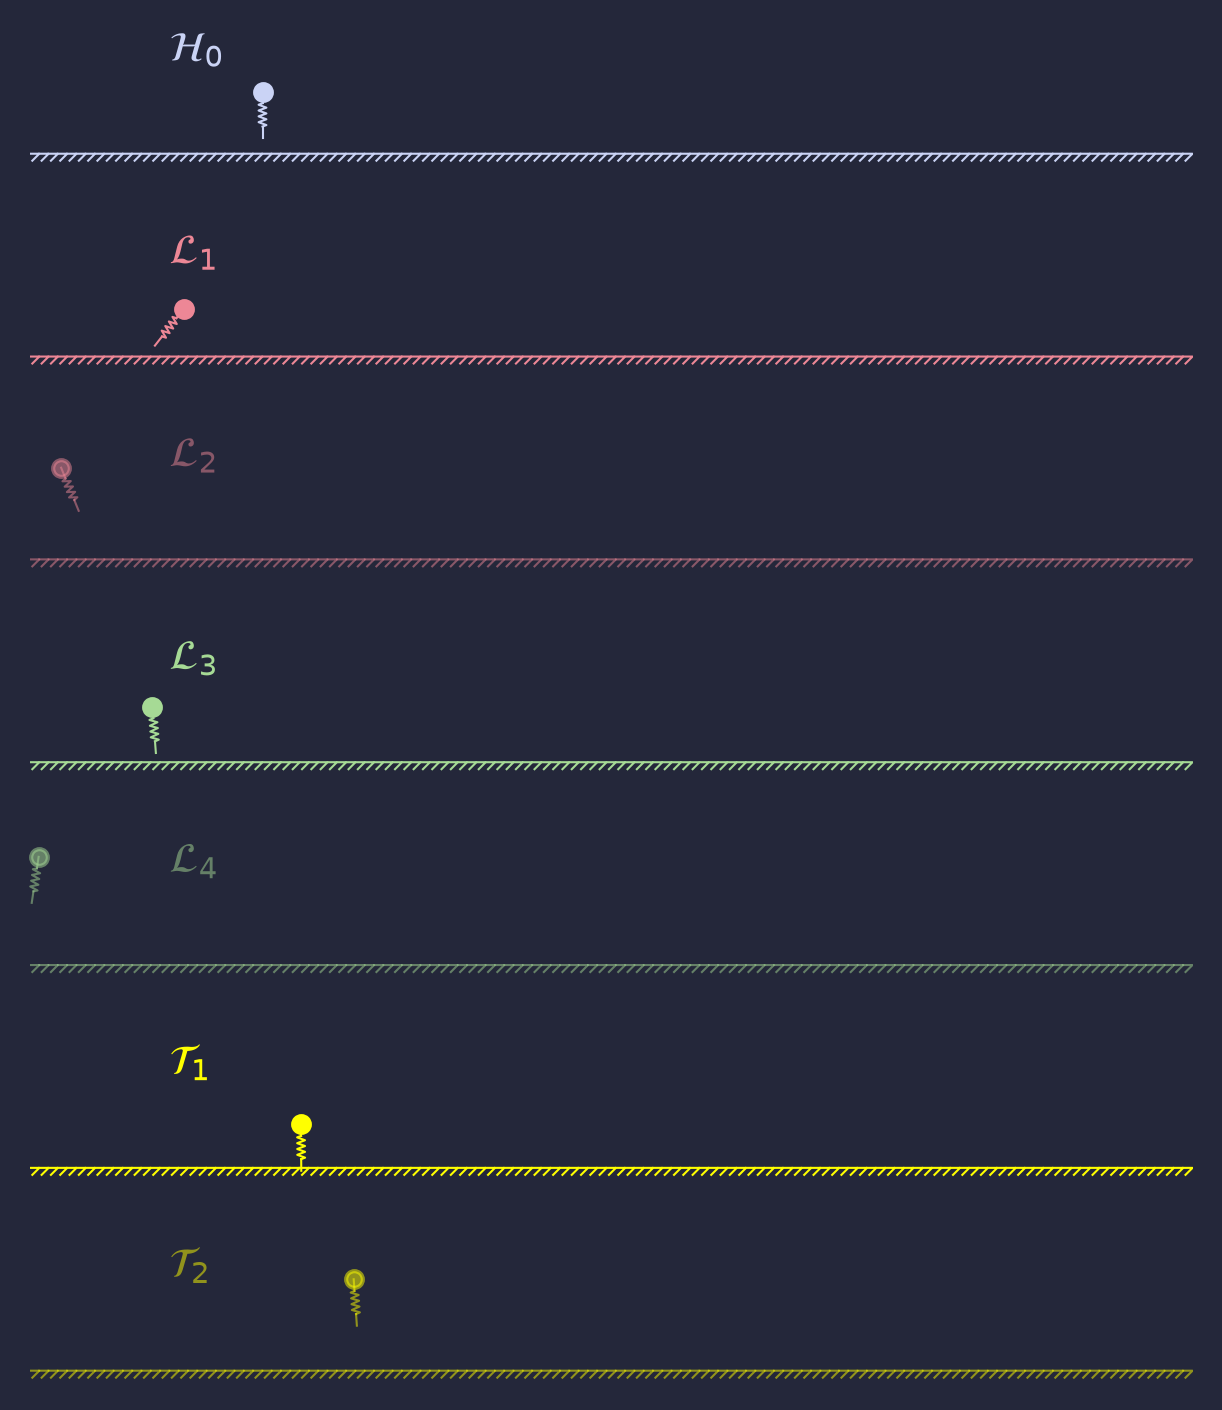

In [14]:


xh1, rh1, ah1 = clean_trajectory(data_locomotion[3][10],60,10)
xh2, rh2, ah2 = clean_trajectory(data_locomotion[2][500],60,20)
xh3, rh3, ah3 = clean_trajectory(data_locomotion[6][500],60,10)
xh4, rh4, ah4 = clean_trajectory(data_locomotion[4][500],60,20)
xh5, rh5, ah5 = clean_trajectory(data_locomotion[8][500],60,10)
xh6, rh6, ah6 = clean_trajectory(data_switch[2][200],60,20,True)
xh7, rh7, ah7 = clean_trajectory(data_switch[4][200],60,10,True)

def process(ax):
    ax.set_xlim(-5,20)
    ax.set_ylim(-0.2, 2.)
    ax.set_aspect("equal")
    ax.set_facecolor(bgColor)
    ax.set(xticklabels=[], yticklabels=[])
    ax.set_axis_off()


def get_points(xh,ah,rh,i):
    if xh[0,i]>21:
        xh[0,i:] += -xh[0,i] - 6
    radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
    x0 = np.array([xh[0,i], xh[1,i]])
    x1 = x0 - 0.25*radial
    x2 = x0 - ( rh[i] - 0.25) * radial
    x3 = x0 - rh[i] * radial
    return x0,x1,x2,x3


def animate(i):

    x0,x1,x2,x3 = get_points(xh1,ah1,rh1,min(i,xh1.shape[1]-1))
    body1.set_data([x0[0]], [x0[1]])
    X, Y = spring(x1, x2,8, 0.18)
    leg1.set_data(X, Y)
    upper_leg1.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg1.set_data([x2[0],x3[0]],[x2[1],x3[1]])

    x0,x1,x2,x3 = get_points(xh2,ah2,rh2,min(i,xh2.shape[1]-1))
    body2.set_data([x0[0]], [x0[1]])
    X, Y = spring(x1, x2,8, 0.18)
    leg2.set_data(X, Y)
    upper_leg2.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg2.set_data([x2[0],x3[0]],[x2[1],x3[1]])

    x0,x1,x2,x3 = get_points(xh3,ah3,rh3,min(i,xh3.shape[1]-1))
    body3.set_data([x0[0]], [x0[1]])
    X, Y = spring(x1, x2,8, 0.18)
    leg3.set_data(X, Y)
    upper_leg3.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg3.set_data([x2[0],x3[0]],[x2[1],x3[1]])

    x0,x1,x2,x3 = get_points(xh4,ah4,rh4,min(i,xh4.shape[1]-1))
    body4.set_data([x0[0]], [x0[1]])
    X, Y = spring(x1, x2,8, 0.18)
    leg4.set_data(X, Y)
    upper_leg4.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg4.set_data([x2[0],x3[0]],[x2[1],x3[1]])

    x0,x1,x2,x3 = get_points(xh5,ah5,rh5,min(i,xh5.shape[1]-1))
    body5.set_data([x0[0]], [x0[1]])
    X, Y = spring(x1, x2,8, 0.18)
    leg5.set_data(X, Y)
    upper_leg5.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg5.set_data([x2[0],x3[0]],[x2[1],x3[1]])

    x0,x1,x2,x3 = get_points(xh6,ah6,rh6,min(i,xh6.shape[1]-1))
    body6.set_data([x0[0]], [x0[1]])
    X, Y = spring(x1, x2,8, 0.18)
    leg6.set_data(X, Y)
    upper_leg6.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg6.set_data([x2[0],x3[0]],[x2[1],x3[1]])

    x0,x1,x2,x3 = get_points(xh7,ah7,rh7,min(i,xh7.shape[1]-1))
    body7.set_data([x0[0]], [x0[1]])
    X, Y = spring(x1, x2,8, 0.18)
    leg7.set_data(X, Y)
    upper_leg7.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg7.set_data([x2[0],x3[0]],[x2[1],x3[1]])




fig = plt.figure(figsize=(5, 6), dpi=300, facecolor=bgColor)
gs = GridSpec(7,7)
ax1 = fig.add_subplot(gs[0,:])
ax2 = fig.add_subplot(gs[1,:])
ax3 = fig.add_subplot(gs[2,:])
ax4 = fig.add_subplot(gs[3,:])
ax5 = fig.add_subplot(gs[4,:])
ax6 = fig.add_subplot(gs[5,:])
ax7 = fig.add_subplot(gs[6,:])

process(ax1)
process(ax2)
process(ax3)
process(ax4)
process(ax5)
process(ax6)
process(ax7)

(leg1,) = ax1.plot([], [], lw=0.5, color=mainColor)
(upper_leg1,) = ax1.plot([], [], lw=0.5, color=mainColor)
(lower_leg1,) = ax1.plot([], [], lw=0.5, color=mainColor)
(body1,) = ax1.plot([], [], "o", ms=4, lw=0, color=mainColor)


(leg2,) = ax2.plot([], [], lw=0.5, color='#ed8796')
(upper_leg2,) = ax2.plot([], [], lw=0.5, color='#ed8796')
(lower_leg2,) = ax2.plot([], [], lw=0.5, color='#ed8796')
(body2,) = ax2.plot([], [], "o", ms=4, lw=0, color='#ed8796')


(leg3,) = ax3.plot([], [], lw=0.5, color='#ed8796',alpha=0.5,clip_on=False)
(upper_leg3,) = ax3.plot([], [], lw=0.5, color='#ed8796',alpha=0.5,clip_on=False)
(lower_leg3,) = ax3.plot([], [], lw=0.5, color='#ed8796',alpha=0.5,clip_on=False)
(body3,) = ax3.plot([], [], "o", ms=4, lw=0, color='#ed8796',alpha=0.5,clip_on=False)


(leg4,) = ax4.plot([], [], lw=0.5, color='#a6da95')
(upper_leg4,) = ax4.plot([], [], lw=0.5, color='#a6da95')
(lower_leg4,) = ax4.plot([], [], lw=0.5, color='#a6da95')
(body4,) = ax4.plot([], [], "o", ms=4, lw=0, color='#a6da95')


(leg5,) = ax5.plot([], [], lw=0.5, color='#a6da95',alpha=0.5,clip_on=False)
(upper_leg5,) = ax5.plot([], [], lw=0.5, color='#a6da95',alpha=0.5,clip_on=False)
(lower_leg5,) = ax5.plot([], [], lw=0.5, color='#a6da95',alpha=0.5,clip_on=False)
(body5,) = ax5.plot([], [], "o", ms=4, lw=0, color='#a6da95',alpha=0.5,clip_on=False)

(leg6,) = ax6.plot([], [], lw=0.5, color='#ffff00')
(upper_leg6,) = ax6.plot([], [], lw=0.5, color='#ffff00')
(lower_leg6,) = ax6.plot([], [], lw=0.5, color='#ffff00')
(body6,) = ax6.plot([], [], "o", ms=4, lw=0, color='#ffff00')


(leg7,) = ax7.plot([], [], lw=0.5, color='#ffff00',alpha=0.5,clip_on=False)
(upper_leg7,) = ax7.plot([], [], lw=0.5, color='#ffff00',alpha=0.5,clip_on=False)
(lower_leg7,) = ax7.plot([], [], lw=0.5, color='#ffff00',alpha=0.5,clip_on=False)
(body7,) = ax7.plot([], [], "o", ms=4, lw=0, color='#ffff00',alpha=0.5,clip_on=False)

length = 25
for i in range(int(length/0.2)):
    ax1.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color=mainColor)
    ax2.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color='#ed8796')
    ax3.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15],alpha=0.5, lw=0.5,color='#ed8796')
    ax4.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color='#a6da95')
    ax5.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15],alpha=0.5, lw=0.5,color='#a6da95')
    ax6.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color='#ffff00')
    ax7.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15],alpha=0.5, lw=0.5,color='#ffff00')

ax1.annotate(r'$\mathcal{H}_0$',(-2,2),color=mainColor)
ax2.annotate(r'$\mathcal{L}_1$',(-2,2),color='#ed8796')
ax3.annotate(r'$\mathcal{L}_2$',(-2,2),color='#ed8796',alpha=0.5)
ax4.annotate(r'$\mathcal{L}_3$',(-2,2),color='#a6da95')
ax5.annotate(r'$\mathcal{L}_4$',(-2,2),color='#a6da95',alpha=0.5)
ax6.annotate(r'$\mathcal{T}_1$',(-2,2),color='#ffff00')
ax7.annotate(r'$\mathcal{T}_2$',(-2,2),color='#ffff00',alpha=0.5)

N = min([xh1.shape[1],xh2.shape[1],xh3.shape[1],xh4.shape[1],xh5.shape[1],xh6.shape[1],xh7.shape[1]])
# N=10
ani = animation.FuncAnimation(fig, animate, N,repeat=True)
writervideo = animation.FFMpegWriter(fps=40)
ani.save("output/trajectories.mp4", writer=writervideo, savefig_kwargs=dict(facecolor=bgColor))

In [61]:
print(solver.energy_flight(xh2[:,0]))

2.39605


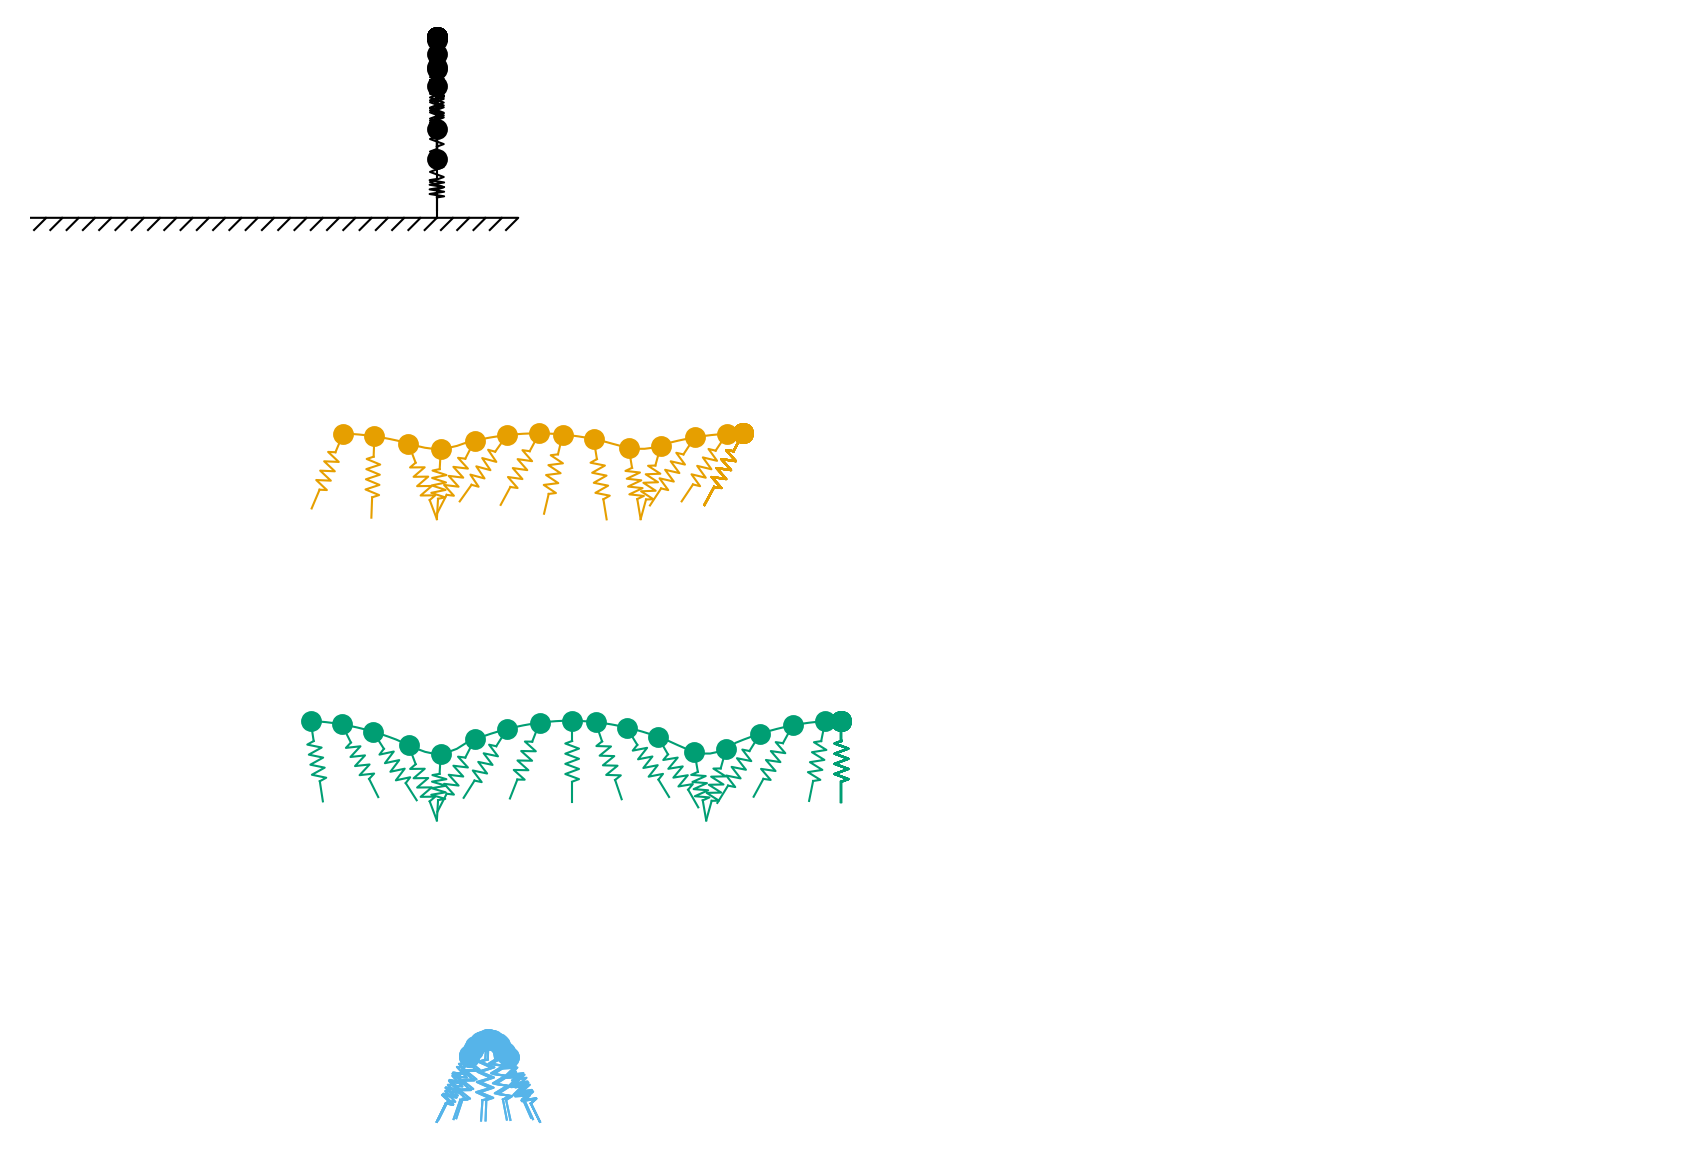

In [87]:


xh1, rh1, ah1 = clean_trajectory(data_locomotion[5][10],18,1)
xh2, rh2, ah2 = clean_trajectory(data_locomotion[2][300],70,1)
# xh3, rh3, ah3 = clean_trajectory(data_locomotion[6][500],60,2)
xh4, rh4, ah4 = clean_trajectory(data_locomotion[4][300],60,1)
# xh5, rh5, ah5 = clean_trajectory(data_locomotion[8][500],60,1)
# xh6, rh6, ah6 = clean_trajectory(data_switch[2][200],60,2,True)
xh6, rh6, ah6 = clean_trajectory(data_switch[2][150],70,1,True)

def process(ax):
    ax.set_xlim(-5,15)
    ax.set_ylim(-0.2, 2.)
    ax.set_aspect("equal")
    ax.set(xticklabels=[], yticklabels=[])
    ax.set_axis_off()


def get_points(xh,ah,rh,i):
    if xh[0,i]>21:
        xh[0,i:] += -xh[0,i] - 6
    radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
    x0 = np.array([xh[0,i], xh[1,i]])
    x1 = x0 - 0.25*radial
    x2 = x0 - ( rh[i] - 0.25) * radial
    x3 = x0 - rh[i] * radial
    return x0,x1,x2,x3


def plot_frame(i):

    x0,x1,x2,x3 = get_points(xh1,ah1,rh1,min(i,xh1.shape[1]-1))
    ax1.plot([x0[0]], [x0[1]],"o", ms=4, lw=0, color='black',clip_on=False)
    X, Y = spring(x1, x2,8, 0.18)
    ax1.plot(X, Y, lw=0.5, color='black',clip_on=False)
    ax1.plot([x0[0],x1[0]],[x0[1],x1[1]], lw=0.5, color='black',clip_on=False)
    ax1.plot([x2[0],x3[0]],[x2[1],x3[1]], lw=0.5, color='black',clip_on=False)

    x0,x1,x2,x3 = get_points(xh2,ah2,rh2,min(i,xh2.shape[1]-1))
    ax2.plot([x0[0]], [x0[1]],"o", ms=4, lw=0, color='#E69F00')
    X, Y = spring(x1, x2,8, 0.18)
    ax2.plot(X, Y, lw=0.5, color='#E69F00')
    ax2.plot([x0[0],x1[0]],[x0[1],x1[1]], lw=0.5, color='#E69F00')
    ax2.plot([x2[0],x3[0]],[x2[1],x3[1]], lw=0.5, color='#E69F00')


    x0,x1,x2,x3 = get_points(xh4,ah4,rh4,min(i,xh4.shape[1]-1))
    ax4.plot([x0[0]], [x0[1]],"o", ms=4, lw=0, color='#009E73')
    X, Y = spring(x1, x2,8, 0.18)
    ax4.plot(X, Y, lw=0.5, color='#009E73')
    ax4.plot([x0[0],x1[0]],[x0[1],x1[1]], lw=0.5, color='#009E73')
    ax4.plot([x2[0],x3[0]],[x2[1],x3[1]], lw=0.5, color='#009E73')


    x0,x1,x2,x3 = get_points(xh6,ah6,rh6,min(i,xh6.shape[1]-1))
    ax6.plot([x0[0]], [x0[1]],"o", ms=4, lw=0, color='#56B4E9',clip_on=False)
    X, Y = spring(x1, x2,8, 0.18)
    ax6.plot(X, Y, lw=0.5, color='#56B4E9')
    ax6.plot([x0[0],x1[0]],[x0[1],x1[1]], lw=0.5, color='#56B4E9')
    ax6.plot([x2[0],x3[0]],[x2[1],x3[1]], lw=0.5, color='#56B4E9')





fig = plt.figure(figsize=(7, 5), dpi=300, facecolor='white')
gs = GridSpec(4,4)
ax1 = fig.add_subplot(gs[0,:])
ax2 = fig.add_subplot(gs[1,:])
# ax3 = fig.add_subplot(gs[2,:])
ax4 = fig.add_subplot(gs[2,:])
# ax5 = fig.add_subplot(gs[4,:])
ax6 = fig.add_subplot(gs[3,:])
# ax7 = fig.add_subplot(gs[6,:])

process(ax1)
process(ax2)
# process(ax3)
process(ax4)
# process(ax5)
process(ax6)
# process(ax7)

ax1.plot(xh1[0,:],xh1[1,:],lw=0.5,color='k')
ax2.plot(xh2[0,:],xh2[1,:],lw=0.5,color='#E69F00')
ax4.plot(xh4[0,:],xh4[1,:],lw=0.5,color='#009E73')
ax6.plot(xh6[0,:],xh6[1,:],lw=0.5,color='#56B4E9')

length = 6
for i in range(int(length/0.2)):
    ax1.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color='black')
    # ax2.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color='black')
    # # ax3.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15],alpha=0.5, lw=0.5,color='black')
    # ax4.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color='black')
    # # ax5.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15],alpha=0.5, lw=0.5,color='black')
    # ax6.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15], lw=0.5,color='black')
    # # ax7.plot([-5+i*0.2,-5+i*0.2 + 0.2,-5+i*0.2 + 0.05],[0,0,-0.15],alpha=0.5, lw=0.5,color='black')

# ax1.annotate(r'$\mathcal{H}_0 \;\; | \;\; E = 1.32 \; [mgl_0]$',(-2,2),color='black')
# ax2.annotate(r'$\mathcal{A}_1^1 \;\; | \;\; E = 2.39 \; [mgl_0]$',(-2,2),color='#E69F00')
# # ax3.annotate(r'$\mathcal{L}_2$',(-2,2),color='black',alpha=0.5)
# ax4.annotate(r'$\mathcal{B}_1^1 \;\; | \;\; E = 4.49 \; [mgl_0]$',(-2,2),color='#009E73')
# # ax5.annotate(r'$\mathcal{L}_4$',(-2,2),color='black',alpha=0.5)
# ax6.set_ylim([-0.2,3])
# ax6.annotate(r'$\mathcal{C}_2 \;\; | \;\; E = 2.48 \; [mgl_0]$',(-2,3),color='#56B4E9',clip_on=False)
# ax7.annotate(r'$\mathcal{T}_2$',(-2,2),color='black',alpha=0.5)

N = max([xh1.shape[1],xh2.shape[1],xh4.shape[1],xh6.shape[1]])
for i in range(1,N,4):
    plot_frame(i)

# plt.tight_layout()
plt.savefig('frames.svg')

In [67]:
def plot_generator_alt(ax,branch,c,lw,STEP_SIZE,IDX,linestyle='-',d=1):
    traj = np.array(branch)
    idx = 0
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 2*STEP_SIZE:
            idx = i

    if traj[-1,3] > 1e-2 or traj[0,3] > 1e-2:
        ax.plot(traj[:idx+1,IDX[0]],d*traj[:idx+1,IDX[1]],d*traj[:idx+1,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],d*traj[idx+1:,IDX[1]],d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)

    elif traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        ax.plot(traj[:idx,IDX[0]],-d*traj[:idx,IDX[1]],-d*traj[:idx,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],-d*traj[idx+1:,IDX[1]],-d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)

def get_TD(M,solver):
    TD = []
    for u in M:
        t = traj(solver,u)
        TD.append(t[:,solver.N_F-1])
    return TD

/tmp/ipykernel_114660/3633610232.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  frame = ax.legend(fontsize=fontsize,labelcolor=fgColor,loc='upper right').get_frame()


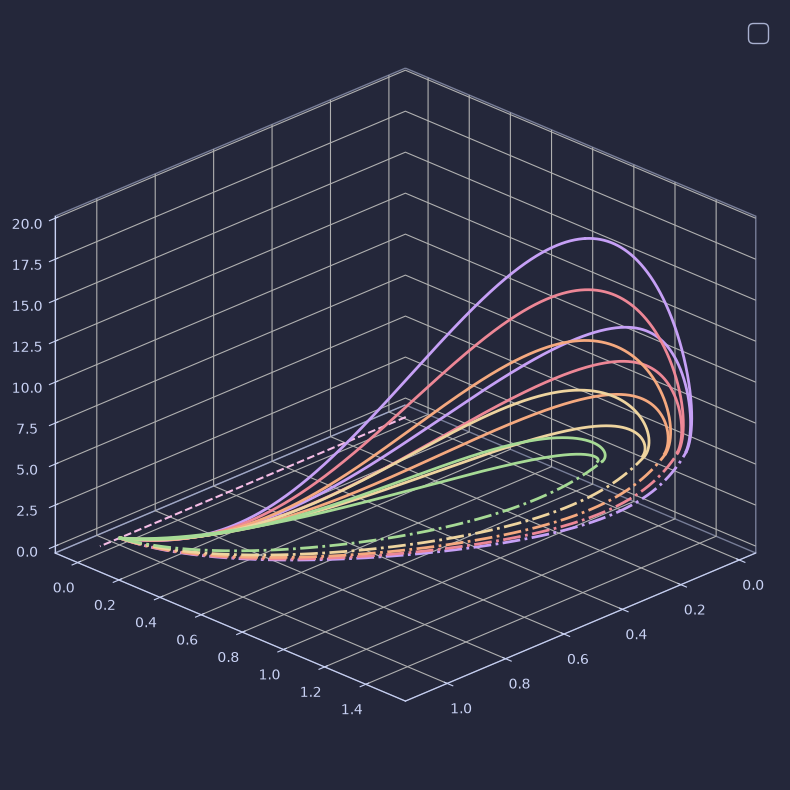

In [71]:

fig_generator = plt.figure(figsize=(10,10),facecolor='#24273a')
ax = fig_generator.add_subplot(1,1,1,projection='3d')
ax.set_proj_type('ortho')
colors = ['#c6a0f6','#ed8796','#f5a97f','#eed49f','#a6da95','#91d7e3']

for w,i in zip([3,2.5,2,1.5,1],range(6)):

    solver = Continuation_Solver(40,w,1000,0.01,True)
    locomotion0 =  pickle.load(open('data/locomotion{}.pkl'.format(i), 'rb'))
    switch0 =  pickle.load(open('data/switch{}.pkl'.format(i), 'rb'))

    idx = [1,2,3]
    for M in locomotion0:
        TD = get_TD(M,solver)
        plot_generator_alt(ax,TD,colors[i],2,0.01,idx)
    for M in switch0:
        TD = get_TD(M,solver)
        plot_generator_alt(ax,TD,colors[i],2,0.01,idx,linestyle='-.')

x_min,x_max = ax.get_xlim()
ax.plot([x_min,x_max],[0,0],[0,0],'--',zorder=0,color='#f5bde6')
prettify3D(ax)
ax.view_init(elev=25, azim=45, roll=0)
# ax.set_xlim(0.6,1)
# ax.set_ylim(0.6,1)
# ax.set_zlim(0.0,5.0)
# ax.set_box_aspect((8,4,3))
plt.savefig('variationsw.svg')